# Density-Based Clustering

## DBSCAN (Baseline)

We adopt DBSCAN as the baseline model for density-based clustering. As both DBSCAN and HDBSCAN rely on distance-based computations, all features are standardised to ensure comparability across dimensions and to prevent scale dominance.

A grid search is conducted over the hyperparameters *(eps, min_samples)* to identify the optimal configuration. Model selection is performed by maximising the silhouette score, which evaluates cluster cohesion and separation in a fully unsupervised manner.

To provide a comprehensive evaluation of clustering performance, the following metrics are reported:

- Adjusted Rand Index (ARI)  
- Normalized Mutual Information (NMI)  
- Calinski–Harabasz Index (CH)  
- Davies–Bouldin Index (DB)  
- F1 score
- Proportion of noise points and cluster size distribution  

Clustering results are further visualised using 2D projections via Principal Component Analysis (PCA) to enable qualitative assessment of cluster structure and separation.

> **Note:** The F1 heatmap and all external evaluation metrics (e.g., ARI, NMI) are reported strictly for reference. They are not used for hyperparameter tuning, as doing so would introduce supervised bias into the clustering process. Model selection and decisions remain fully unsupervised and are based solely on intrinsic metrics.

In [1]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np
from scipy.stats import mode

# Preprocessing & encoding 
from sklearn.preprocessing import LabelEncoder

# Clustering
import hdbscan
from sklearn.cluster import DBSCAN

# Dimensionality reduction 
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib
import os


In [2]:
# Read data file (We will import Set_D's features because the redshift is logged)
# We are only selecting the features from set B, which are the band differences and redshift_log
df = pd.read_csv("../astral_data.csv")
df.head()

,u-g,g-r,r-i,i-z,redshift_log,class
0,1.89183,0.97312,0.44642,0.33393,-1.036525,GALAXY
1,1.74284,0.96594,0.53794,0.34925,-1.181723,GALAXY
2,1.44872,0.85088,0.41556,0.32810,-1.068913,GALAXY
3,1.97767,0.94814,0.45569,0.35529,-1.054971,GALAXY
4,1.48383,0.68268,0.41322,0.19883,-1.102157,GALAXY


In [3]:
# Separate relevant features from class
X = df[['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']].copy()
y = df['class']
X.head()

,u-g,g-r,r-i,i-z,redshift_log
0,1.89183,0.97312,0.44642,0.33393,-1.036525
1,1.74284,0.96594,0.53794,0.34925,-1.181723
2,1.44872,0.85088,0.41556,0.32810,-1.068913
3,1.97767,0.94814,0.45569,0.35529,-1.054971
4,1.48383,0.68268,0.41322,0.19883,-1.102157


### DBSCAN Clustering (band diff + redshift_log)

DBSCAN model saved to ../models/dbscan_model.pkl
band diff + redshift_log: eps=0.3, min_samples=10

Silhouette: 0.6543
F1 (macro): 0.6545
ARI: 0.5826
NMI: 0.5326
Calinski-Harabasz: 2476.6912
Davies-Bouldin: 0.3750
Noise %: 3.1%

band diff + redshift_log — Cluster Composition
──────────────────────────────────────────────────
       Noise:   306 points (3.1%)
   Cluster 0:  8931 points (91.8%)
   Cluster 1:   485 points (5.0%)
   Cluster 2:    11 points (0.1%)


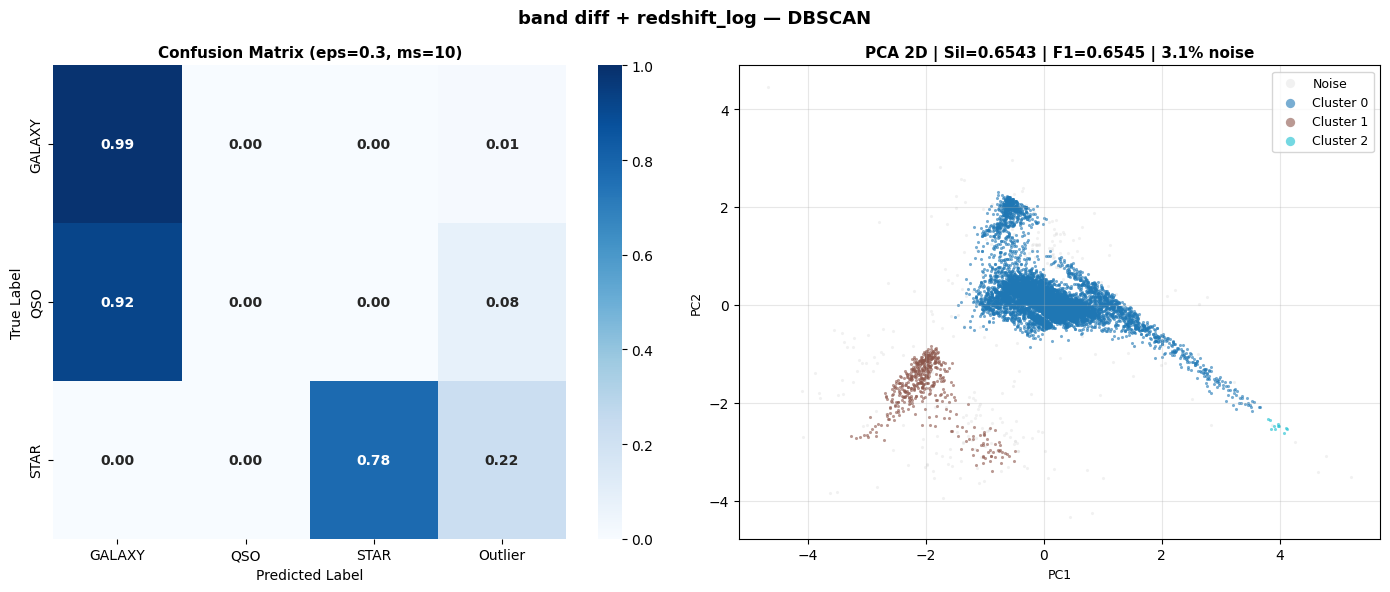

In [4]:
# Prepare Dataset (band diff + redshift_log)
df1 = X.copy()
title = 'band diff + redshift_log'

# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)

# Helper function for cluster -> class mapping (majority voting) for f1
def map_clusters_to_labels(y_true, labels):
    mapped = np.full_like(labels, fill_value=-1)
    for cluster in set(labels):
        if cluster == -1:
            continue  # skip noise
        mask = labels == cluster
        majority_label = mode(y_true[mask], keepdims=True).mode[0]
        mapped[mask] = majority_label
    return mapped

# Grid search eps/min_samples (target: 3 clusters) 
best_sil = -1
best_cfg = None

for eps in np.arange(0.1, 5.0, 0.1):
    for ms in [3, 5, 10, 15, 20]:
        db = DBSCAN(eps=round(eps, 1), min_samples=ms).fit(df1)
        labels = db.labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters != 3: 
            continue

        mask = labels != -1
        if mask.sum() == 0:
            continue

        sil = silhouette_score(df1[mask], labels[mask])

        if sil > best_sil:
            best_sil = sil
            best_cfg = (round(eps, 1), ms, labels.copy())

# Save the DBSCAN model
os.makedirs('../models', exist_ok=True)
joblib.dump(db, '../models/dbscan_model.pkl')
print("DBSCAN model saved to ../models/dbscan_model.pkl")

# Final evaluation + metrics
if best_cfg is None:
    print("No valid configuration found with exactly 3 clusters.")
else:
    eps_best, ms_best, labels = best_cfg
    y_pred = map_clusters_to_labels(y_true, labels)
    mask = labels != -1

    sil = silhouette_score(df1[mask], labels[mask]) if mask.sum() > 1 else float('nan')
    f1 = f1_score(y_true[mask], y_pred[mask], average='macro')
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    noise_pct = (labels == -1).mean() * 100
    ch = calinski_harabasz_score(df1[mask], labels[mask])
    db_index = davies_bouldin_score(df1[mask], labels[mask])

    print(f"{title}: eps={eps_best}, min_samples={ms_best}")
    print(f"\nSilhouette: {sil:.4f}")
    print(f"F1 (macro): {f1:.4f}")
    print(f"ARI: {ari:.4f}")
    print(f"NMI: {nmi:.4f}")
    print(f"Calinski-Harabasz: {ch:.4f}")
    print(f"Davies-Bouldin: {db_index:.4f}")
    print(f"Noise %: {noise_pct:.1f}%")

unique, counts = np.unique(labels, return_counts=True)
print(f"\n{title} — Cluster Composition")
print("─" * 50)
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {name:>10}: {cnt:>5} points ({cnt/len(labels)*100:.1f}%)")

class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')
n = len(y_true)

# Plot diagrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'{title} — DBSCAN', fontsize=13, fontweight='bold')

# Heatmap 
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[y_pred[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            ax=axes[0], annot_kws={'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_title(f'Confusion Matrix (eps={eps_best}, ms={ms_best})', fontsize=11, fontweight='bold')

# Visualisation (PCA 2D) 
X2d = PCA(n_components=2, random_state=42).fit_transform(df1)

unique_labels = sorted(set(labels))
cmap = plt.get_cmap('tab10', 3)

for k in unique_labels:
    mask_k = labels == k
    color = 'lightgrey' if k == -1 else cmap(k)
    lbl = 'Noise' if k == -1 else f'Cluster {k}'
    axes[1].scatter(
        X2d[mask_k, 0], X2d[mask_k, 1],
        c=[color], s=5,
        alpha=0.3 if k == -1 else 0.6,
        label=lbl, linewidths=0
    )

axes[1].set_title(
    f'PCA 2D | Sil={sil:.4f} | F1={f1:.4f} | {noise_pct:.1f}% noise',
    fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('PC1', fontsize=9)
axes[1].set_ylabel('PC2', fontsize=9)
axes[1].legend(fontsize=9, markerscale=3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


DBSCAN results with hyperparameters *(eps = 0.3, min_samples = 10)* :

Cluster Composition
The model identifies two dominant clusters and a minor fragment:
- Cluster 0: 8,931 points (91.8%)  
- Cluster 1: 485 points (5.0%)  
- Cluster 2: 11 points (0.1%)  
- Noise: 306 points (3.1%)

The PCA projection shows that **Cluster 0 dominates**, while Cluster 2 is poorly separated, likely merged with cluster 0 rather than being a meaningful class.

Simple Evaluation Metrics (only for reference)
- **ARI: 0.5826 | NMI: 0.5326**  
  Moderate agreement with ground truth; STAR vs GALAXY separation is captured, but QSO is not
- **F1 (macro): 0.6545**  
  Low due to failure in isolating QSOs (≈92% absorbed into the GALAXY-dominated cluster)

Key Limitations
- **Hyperparameter Sensitivity**  
  Cluster results can differ greatly based on hyperparameters chosen
- **Varying Densities**  
  2 of the clusters' regions most likely overlap in density, causing them to merge into a dominant cluster

Conclusion:

DBSCAN is not well-suited for this dataset, effectively collapsing a three-class problem into two clusters and failing to isolate QSOs (in hindsight). A more flexible approach such as **HDBSCAN** (for varying densities based on what we see from the PCA plot)

### HDBSCAN

As mentioned, this algorithm is well-suited for datasets with varying densities and cluster sizes. HDBSCAN extends DBSCAN by incorporating a hierarchical clustering framework and extracting flat clusters based on cluster stability. Unlike DBSCAN, which relies on a single global density threshold, HDBSCAN constructs a hierarchy of clusters using a minimum spanning tree representation of the data. This hierarchical approach allows HDBSCAN to adapt to local density variations, enabling the detection of clusters that differ in density and structure. As a result, it is more robust in complex datasets where traditional density-based methods, such as DBSCAN, struggle to separate overlapping or unevenly distributed regions (Amalina & Fauzan, 2024)

The grid search ranges for `min_cluster_size` in this study were inspired by Logan & Fotopoulou (2020), who demonstrated that carefully exploring these hyperparameters helps HDBSCAN identify meaningful structures in astronomical datasets while balancing the trade-off between cluster granularity and noise.


Best min_cluster_size: mcs=160, Silhouette=0.6506

── Overall Metrics ─────────────────────────────────────
  Outliers: 914 (9.4%)
  ARI:      0.7617
  NMI:      0.6342

Calinski-Harabasz: 6029.5476  Davies-Bouldin: 0.3791  Silhouette: 0.6506

── Cluster sizes ────
  Noise: 914 points (9.4%)
  Cluster 0: 388 points (4.0%)
  Cluster 1: 418 points (4.3%)
  Cluster 2: 8,013 points (82.3%)

── Per-class F1 (incl. outliers as misclassified) ──────
  GALAXY: F1=0.9690
     QSO: F1=0.7579
    STAR: F1=0.7660


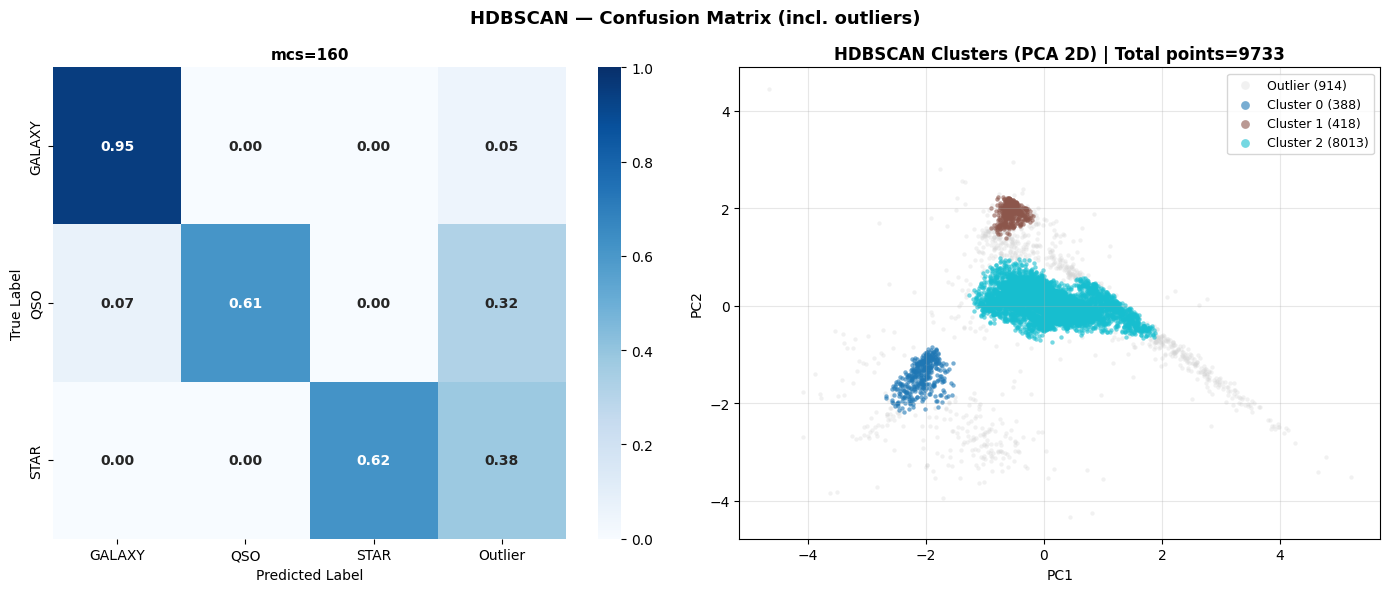

In [5]:
# Encode classes 
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

n = len(y_true)

# Grid search parameters 
mcs_values = (
    list(range(2,   70,   1))  +
    list(range(70,  100,  2))  +
    list(range(100, 120,  5))  +
    list(range(120, 200, 20))  
    # list(range(200, 500, 50))  +
    # list(range(500, 1000, 100))
)

best = {'silhouette': -1, 'mcs': None, 'labels': None, 'ch': None, 'db': None, 'model': None}

# HDBSCAN Grid Search 
for mcs in mcs_values:
    clf = hdbscan.HDBSCAN(min_cluster_size=mcs, metric='euclidean').fit(X)
    hard_labels = clf.labels_

    # Skip if fewer than 2 clusters (ignoring noise)
    n_clusters = len(set(hard_labels[hard_labels != -1]))
    if n_clusters < 2:
        continue

    # Compute silhouette score for this clustering (used for optimisation)
    valid_mask = hard_labels != -1
    silhouette = silhouette_score(X.values[valid_mask], hard_labels[valid_mask])

    if silhouette > best['silhouette']:
        # Save best mcs and corresponding labels & metrics
        best['silhouette'] = silhouette
        best['mcs'] = mcs
        best['model'] = clf

        # Map clusters -> class (majority vote)
        cluster_to_class = {}
        for lbl in [l for l in sorted(set(hard_labels)) if l != -1]:
            mask = hard_labels == lbl
            majority = mode(y_true[mask], keepdims=True).mode[0]
            cluster_to_class[lbl] = majority

        # Assign cluster points to class
        final_labels = np.full(n, -1)
        for i in range(n):
            lbl = hard_labels[i]
            if lbl != -1:
                final_labels[i] = cluster_to_class[lbl]
        best['labels'] = final_labels.copy()

        # Internal metrics
        best['ch'] = calinski_harabasz_score(X.values[valid_mask], hard_labels[valid_mask])
        best['db'] = davies_bouldin_score(X.values[valid_mask], hard_labels[valid_mask])

final_labels = best['labels']

# Report best mcs 
print(f"\nBest min_cluster_size: mcs={best['mcs']}, Silhouette={best['silhouette']:.4f}")

# Overall metrics 
noise_pct = (final_labels == -1).mean() * 100
ari = adjusted_rand_score(y_true, final_labels)
nmi = normalized_mutual_info_score(y_true, final_labels)

print("\n── Overall Metrics ─────────────────────────────────────")
print(f"  Outliers: {(final_labels==-1).sum()} ({noise_pct:.1f}%)")
print(f"  ARI:      {ari:.4f}")
print(f"  NMI:      {nmi:.4f}")

# Internal metrics 
print(f"\nCalinski-Harabasz: {best['ch']:.4f}  Davies-Bouldin: {best['db']:.4f}  Silhouette: {best['silhouette']:.4f}")

# Cluster sizes including outliers 
raw_labels = best['model'].labels_
unique, counts = np.unique(raw_labels, return_counts=True)
print("\n── Cluster sizes ────")
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {name}: {cnt:,} points ({cnt/len(raw_labels)*100:.1f}%)")

# Per-class F1 
print("\n── Per-class F1 (incl. outliers as misclassified) ──────")
for cls_name, cls_idx in [('GALAXY', GAL_IDX), ('QSO', QSO_IDX), ('STAR', STAR_IDX)]:
    y_bin_true = (y_true == cls_idx).astype(int)
    y_bin_pred = (final_labels == cls_idx).astype(int)
    f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
    print(f"  {cls_name:>6}: F1={f1:.4f}")

# Plot diagrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('HDBSCAN — Confusion Matrix (incl. outliers)',
             fontsize=13, fontweight='bold')

# Heatmap 
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[final_labels[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            ax=axes[0], annot_kws={'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_title(f'mcs={best["mcs"]}', fontsize=11, fontweight='bold')

# Plot Visualisation 
X2d = PCA(n_components=2, random_state=42).fit_transform(X)

unique_labels = sorted(set(final_labels))
cmap = plt.get_cmap('tab10', len(class_names))

for lbl in unique_labels:
    mask = raw_labels == lbl
    if lbl == -1:
        color = 'lightgrey'
        label_name = 'Outlier'
        alpha = 0.3
    else:
        color = cmap(lbl)
        label_name = f'Cluster {lbl}'
        alpha = 0.6
    axes[1].scatter(X2d[mask, 0], X2d[mask, 1],
                    c=[color], s=10, alpha=alpha,
                    label=f"{label_name} ({mask.sum()})", linewidths=0)

axes[1].set_title(f'HDBSCAN Clusters (PCA 2D) | Total points={n}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=10)
axes[1].set_ylabel('PC2', fontsize=10)
axes[1].legend(fontsize=9, markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Applying HDBSCAN with a minimum cluster size (mcs) of 160 significantly improved the separation of clusters compared to DBSCAN. The model now identifies 3 distinct clusters corresponding to the astronomical classes (GALAXY, QSO, and STAR). This demonstrates that the hierarchical approach and the minimum cluster size parameter help HDBSCAN adapt to varying densities and avoid merging smaller clusters into a dominant mega-cluster, which was a limitation of DBSCAN.  

However, the model also identifies a relatively large number of outliers (914 points, 9.4%). This is a consequence of the large min_cluster_size, which prevents smaller dense pockets from forming separate clusters. While this reduces false merging of clusters, it also increases the number of points labeled as noise.  

Overall, HDBSCAN effectively captures the underlying three-class structure with improved cluster separation, while the choice of min_cluster_size balances cluster robustness against the number of outliers.

### HDBSCAN + tweak min_samples

For the final HDBSCAN model, we will keep `min_cluster_size` (mc) fixed at 160 to preserve robust cluster detection for the main astronomical populations. However, we will adjust `min_samples` and perform a grid search over `[5, 10, 15, 20, 25, 30]`.  

By default, if `min_samples` is not specified, HDBSCAN sets it equal to `mc`. This makes the criterion for a core point very strict, resulting in more points being labeled as outliers. Reducing `min_samples` relaxes the core point requirement, making it easier to form clusters and reducing the number of outliers, which is desirable in this dataset since we expect only minimal noise.


Best min_cluster_size: mcs=160, min_samples=25, Silhouette=0.6143

── Overall Metrics ─────────────────────────────────────
  Outliers: 487 (5.0%)
  ARI:      0.8260
  NMI:      0.7101

Calinski-Harabasz: 5765.5371  Davies-Bouldin: 0.4587  Silhouette: 0.6143

── Cluster sizes ────
  Noise: 487 points (5.0%)
  Cluster 0: 543 points (5.6%)
  Cluster 1: 452 points (4.6%)
  Cluster 2: 8,251 points (84.8%)

── Per-class F1 (incl. outliers as misclassified) ──────
  GALAXY: F1=0.9785
     QSO: F1=0.7951
    STAR: F1=0.9247
HDBSCAN model saved as '../models/hdbscan_model.pkl'


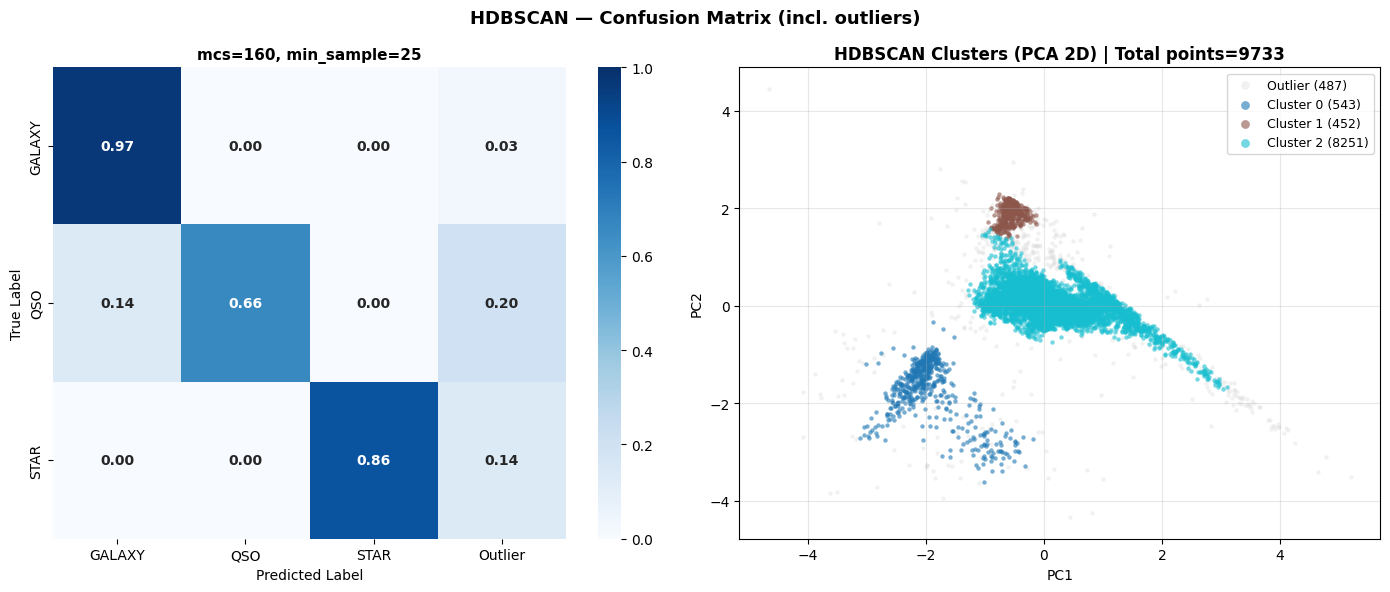

In [6]:
# Encode classes 
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

n = len(y_true)

# HDBSCAN model
mcs = 160

best = {'silhouette': -1, 'min_samples': None, 'labels': None, 'ch': None, 'db': None, 'model': None}

for min_samples in range(5, 31, 5):

    clf = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=min_samples,
        metric='euclidean'
    ).fit(X)

    hard_labels = clf.labels_

    # Skip if fewer than 2 clusters (ignoring noise)
    n_clusters = len(set(hard_labels[hard_labels != -1]))
    if n_clusters < 2:
        continue

    # Report metrics
    valid_mask = hard_labels != -1
    if valid_mask.sum() < 2:
        continue

    silhouette = silhouette_score(X.values[valid_mask], hard_labels[valid_mask])

    if silhouette > best['silhouette']:
        best['silhouette'] = silhouette
        best['min_samples'] = min_samples
        best['model'] = clf

        # Map clusters -> class (majority vote)
        cluster_to_class = {}
        for lbl in [l for l in sorted(set(hard_labels)) if l != -1]:
            mask = hard_labels == lbl
            majority = mode(y_true[mask], keepdims=True).mode[0]
            cluster_to_class[lbl] = majority

        # Assign cluster points to class
        final_labels = np.full(n, -1)
        for i in range(n):
            lbl = hard_labels[i]
            if lbl != -1:
                final_labels[i] = cluster_to_class[lbl]
        best['labels'] = final_labels.copy()

        # Internal metrics
        best['ch'] = calinski_harabasz_score(X.values[valid_mask], hard_labels[valid_mask])
        best['db'] = davies_bouldin_score(X.values[valid_mask], hard_labels[valid_mask])

final_labels = best['labels']
min_samples = best['min_samples']

print(f"\nBest min_cluster_size: mcs={mcs}, min_samples={min_samples}, Silhouette={best['silhouette']:.4f}")

# Overall metrics 
noise_pct = (final_labels == -1).mean() * 100
ari = adjusted_rand_score(y_true, final_labels)
nmi = normalized_mutual_info_score(y_true, final_labels)

print("\n── Overall Metrics ─────────────────────────────────────")
print(f"  Outliers: {(final_labels==-1).sum()} ({noise_pct:.1f}%)")
print(f"  ARI:      {ari:.4f}")
print(f"  NMI:      {nmi:.4f}")

# Internal metrics 
print(f"\nCalinski-Harabasz: {best['ch']:.4f}  Davies-Bouldin: {best['db']:.4f}  Silhouette: {best['silhouette']:.4f}")

# Cluster sizes including outliers 
raw_labels = best['model'].labels_
unique, counts = np.unique(raw_labels, return_counts=True)
print("\n── Cluster sizes ────")
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {name}: {cnt:,} points ({cnt/len(raw_labels)*100:.1f}%)")

# Per-class F1 
print("\n── Per-class F1 (incl. outliers as misclassified) ──────")
for cls_name, cls_idx in [('GALAXY', GAL_IDX), ('QSO', QSO_IDX), ('STAR', STAR_IDX)]:
    y_bin_true = (y_true == cls_idx).astype(int)
    y_bin_pred = (final_labels == cls_idx).astype(int)
    f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
    print(f"  {cls_name:>6}: F1={f1:.4f}")

# Save model
joblib.dump(best['model'], "../models/hdbscan_model.pkl")
print("HDBSCAN model saved as '../models/hdbscan_model.pkl'")

# Plot diagrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('HDBSCAN — Confusion Matrix (incl. outliers)',
             fontsize=13, fontweight='bold')

# Heatmap 
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[final_labels[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            ax=axes[0], annot_kws={'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_title(f'mcs={mcs}, min_sample={best["min_samples"]}', fontsize=11, fontweight='bold')

# Plot Visualisation 
X2d = PCA(n_components=2, random_state=42).fit_transform(X)

unique_labels = sorted(set(final_labels))
cmap = plt.get_cmap('tab10', len(class_names))

for lbl in unique_labels:
    mask = raw_labels == lbl
    if lbl == -1:
        color = 'lightgrey'
        label_name = 'Outlier'
        alpha = 0.3
    else:
        color = cmap(lbl)
        label_name = f'Cluster {lbl}'
        alpha = 0.6
    axes[1].scatter(X2d[mask, 0], X2d[mask, 1],
                    c=[color], s=10, alpha=alpha,
                    label=f"{label_name} ({mask.sum()})", linewidths=0)

axes[1].set_title(f'HDBSCAN Clusters (PCA 2D) | Total points={n}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=10)
axes[1].set_ylabel('PC2', fontsize=10)
axes[1].legend(fontsize=9, markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

For the final HDBSCAN model, with `min_cluster_size` = 160 and `min_samples` = 25, the results show improved cluster assignment and fewer outliers. The overall metrics indicate strong performance:

- Outliers: 487 points (5.0%)  
- ARI: 0.8260  
- NMI: 0.7101  
- Per-class F1 scores: GALAXY 0.9785, QSO 0.7951, STAR 0.9247  

As seen from the PCA visualization and cluster sizes, many points previously labeled as outliers now merge into the main clusters, reflecting better cluster cohesion. Although the silhouette score decreased slightly to 0.6143, this is expected as silhouette alone does not fully capture cluster quality and we should look at the PCA diagram too, especially for hierarchical density-based clustering.  

The F1 heatmap is also generated for all models to visualize improvements, but the model selection and tuning logic rely primarily on the PCA diagrams and internal metrics. The F1 scores serve as a reference and are not used to guide the training or hyperparameter selection.

### References:
1. https://eprints.uad.ac.id/83114/1/58021-188825-2-PB.pdf
2. https://www.aanda.org/articles/aa/full_html/2020/01/aa36648-19/aa36648-19.html#S14
